In [1]:
import os
from skimage.metrics import structural_similarity
from skimage.metrics import mean_squared_error
import math
import numpy as np
import sirf.Gadgetron as pMR
import matplotlib.pyplot as plt


data_path = '/home/jovyan/work/SIRF-Contribs/src/notebooks/'
os.chdir(data_path)
import utils
from utils import plot_rpe_3d, plot_rpe_3d_simple

# Can use either of these two as ground truth
# ground_truth_with_TV = np.load(os.path.join(data_path, 'ground_truth_with_TV.npy'))
# ground_truth_no_TV = np.load(os.path.join(data_path, 'ground_truth_no_TV.npy'))


Nms = 3
file_pattern = r'{}_L2_ms_{:d}_it_{:03d}.h5'

crop = 20


recons = []
for ms in range(Nms):
    _fname = os.path.join(data_path, 'recons_ignore-acq_4bis', f'MS_{Nms}', file_pattern.format('FISTA', ms, 20) )
    recons.append( pMR.ImageData(file=_fname).as_array()[crop:-crop,:,:] )




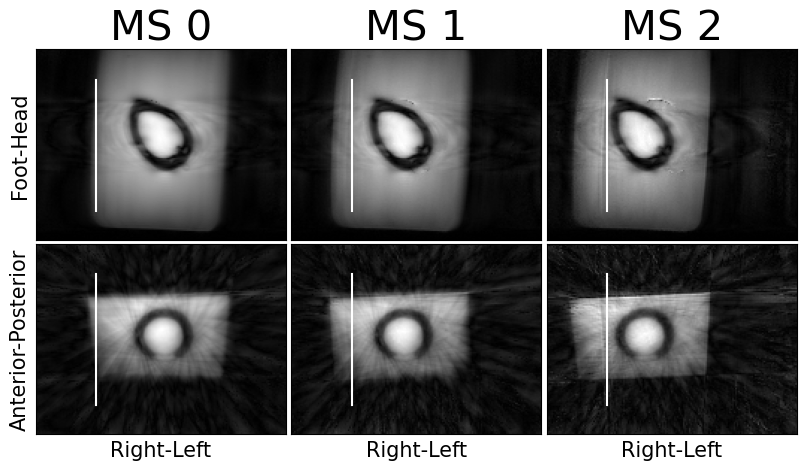

In [19]:
import importlib
# increase the font size
import matplotlib.pylab as pylab
params = {'axes.titlesize':'30', 'axes.labelsize':'15'}
pylab.rcParams.update(params)

importlib.reload(utils)
from utils import plot_rpe_3d_simple

slice_index = [64, 64]

wspace=-0.03
hspace=0.02
fig, ax = plt.subplots(2,len(recons), squeeze=True, figsize=(10,5), gridspec_kw={'wspace':wspace, 'hspace':hspace})

plot_rpe_3d_simple(recons, slice_index * 3, [f'MS {i}' for i in range(Nms)], ax=ax)
# add vertical line
pos=60-crop
x = np.linspace(pos, pos, 2)
y = np.linspace(20, 108, 2)
color="white"

ax[0,0].plot(x,y,'-',color=color)
ax[0,1].plot(x,y,'-',color=color)
ax[0,2].plot(x,y,'-',color=color)
ax[1,0].plot(x,y,'-',color=color)
ax[1,1].plot(x,y,'-',color=color)
ax[1,2].plot(x,y,'-',color=color)

plt.savefig('motion_state_example.png')
plt.show()

<Figure size 640x480 with 0 Axes>

In [41]:
recons[0].shape

(208, 128, 128)